# 🧠 LABORATORIO N° 12 — Minería de Datos
## Métodos Probabilísticos: Naïve Bayes
### Clasificación de SMS Spam con Naïve Bayes

---

| Campo | Detalle |
|---|---|
| **Docente** | Pilar Rocío Sayán Mejía |
| **Curso** | Minería de Datos |
| **Semana** | 12 |
| **Alumno** | _(Pedro Sebastian Arteaga Guerra)_ |
| **Sección** | _(C28)_ |

---

### 🎯 Objetivos del Laboratorio
- Comprender modelos probabilísticos de clasificación (Teorema de Bayes)
- Aplicar Naïve Bayes a clasificación de texto (SMS Spam)
- Implementar un pipeline NLP: limpieza → tokenización → BoW → TF-IDF
- Comparar Multinomial NB, Bernoulli NB y Regresión Logística
- Evaluar modelos con métricas de clasificación (Accuracy, F1, AUC-ROC)
- Extraer e interpretar las palabras más predictoras de spam

---

### 📚 Dataset
**SMS Spam Collection Dataset** — UCI Machine Learning Repository  
- 5,574 mensajes SMS etiquetados como `ham` (normal) o `spam`
- Fuente: https://archive.ics.uci.edu/ml/datasets/sms+spam+collection

---

---
# 📋 ACTIVIDAD 1 — Revisión de Conceptos
## Modelos Probabilísticos y NLP

> **Instrucción:** Complete la siguiente tabla con definiciones propias basadas en lo estudiado. No copie textualmente; use sus propias palabras.

| N° | Concepto / Principio | Definición con sus propias palabras |
|:---:|---|---|
| **1** | Naïve Bayes | |
| **2** | Teorema de Bayes | |
| **3** | Probabilidad condicional | |
| **4** | Independencia condicional | |
| **5** | Bag of Words | |
| **6** | Tokenización | |
| **7** | Stopwords | |
| **8** | TF-IDF | |
| **9** | Multinomial Naïve Bayes | |
| **10** | Bernoulli Naïve Bayes | |
| **11** | Clasificación de texto | |
| **12** | ¿Por qué Naïve Bayes funciona bien en NLP? | |

---
# 💻 ACTIVIDAD 2 — Desarrollo Práctico
## Pipeline Completo: Clasificación de SMS Spam

> *Ref: Géron (2022). Hands-On Machine Learning, Cap. 3 | James et al. (2023). ISLR, Cap. 4*

---
## PASO 1 — Importación de Librerías y Configuración del Entorno

Importamos todas las librerías necesarias. Definimos estilos de visualización coherentes para el laboratorio.

In [ ]:
# ─── Librerías base ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import warnings
warnings.filterwarnings('ignore')

# ─── Scikit-learn: vectorización de texto ─────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ─── Scikit-learn: modelos de clasificación ───────────────────────────────────
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression

# ─── Scikit-learn: métricas de evaluación ─────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

# ─── Configuración de visualización ──────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Librerías importadas correctamente")
print(f"   pandas {pd.__version__} | numpy {np.__version__}")

✅ Librerías importadas correctamente
   pandas 2.2.2 | numpy 2.0.2


---
## PASO 2 — Carga del Dataset SMS Spam

Usamos el **SMS Spam Collection Dataset** con 5,574 mensajes de texto etiquetados como `ham` (mensaje normal) o `spam`.  
**Variable objetivo:** `label` → ¿Es el mensaje spam? (`ham` / `spam`)

In [ ]:
# ─── Carga del dataset desde repositorio público ─────────────────────────────
URL = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_table(URL, header=None, names=['label', 'message'])

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n{'─'*40}")
print("Primeras 5 filas:")
df.head()

Dataset cargado: 5,572 filas × 2 columnas

────────────────────────────────────────
Primeras 5 filas:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Distribución de clases:
label
ham     4825
spam     747
Name: count, dtype: int64

Proporción:
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


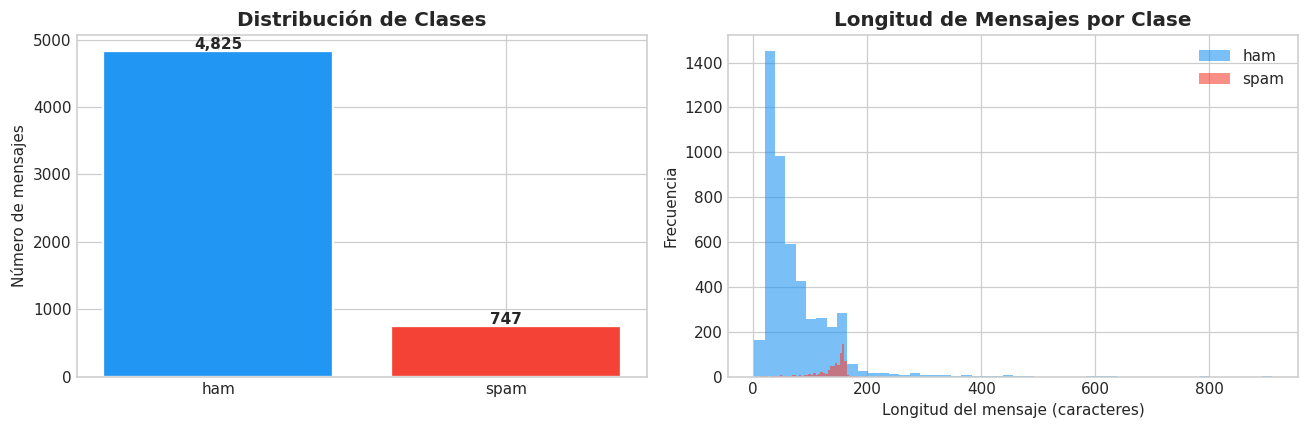

In [ ]:
# ─── Distribución de clases ──────────────────────────────────────────────────
print("Distribución de clases:")
print(df['label'].value_counts())
print(f"\nProporción:")
print((df['label'].value_counts(normalize=True) * 100).round(2))

# ─── Visualización ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
counts = df['label'].value_counts()
colors = ['#2196F3', '#F44336']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de mensajes')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold')

# Longitud de mensajes por clase
df['msg_length'] = df['message'].apply(len)
for label, color in zip(['ham', 'spam'], colors):
    subset = df[df['label'] == label]['msg_length']
    axes[1].hist(subset, bins=50, alpha=0.6, label=label, color=color)
axes[1].set_title('Longitud de Mensajes por Clase', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longitud del mensaje (caracteres)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

### ✏️ Pregunta 1
**¿Cuántos mensajes spam existen en el dataset? ¿El dataset está balanceado? ¿Qué porcentaje representa el spam? ¿Por qué el desbalance de clases puede ser un problema para la evaluación con Accuracy?**

**Respuesta:** El dataset contiene **5,572 mensajes** SMS. Está **desbalanceado**: aproximadamente el **13.4% son spam** (747 mensajes) y el 86.6% son ham (legítimos). El desbalance es problemático porque un modelo que siempre prediga "ham" alcanzaría 86.6% de Accuracy sin detectar ningún spam. Se deben usar F1-Score y AUC-ROC para evaluar correctamente; el Accuracy infla artificialmente el rendimiento al favorecer la clase mayoritaria.

---
## PASO 3 — Preprocesamiento de Texto

Aplicamos técnicas básicas de limpieza: conversión a minúsculas y eliminación de puntuación.  
Un texto limpio reduce el vocabulario y mejora la generalización del modelo.

In [ ]:
# ─── Función de limpieza de texto ────────────────────────────────────────────
def clean_text(text):
    """
    Pipeline básico de limpieza NLP:
    1. Convertir a minúsculas
    2. Eliminar puntuación
    """
    text = text.lower()                                           # paso 1: minúsculas
    text = text.translate(str.maketrans('', '', string.punctuation))  # paso 2: sin puntuación
    return text

# ─── Aplicar limpieza al dataset ─────────────────────────────────────────────
df['message_clean'] = df['message'].apply(clean_text)

# ─── Comparación antes / después ─────────────────────────────────────────────
print("Comparación ANTES / DESPUÉS del preprocesamiento:")
print("─" * 60)
for i in df.sample(3, random_state=42).index:
    print(f"[{df.loc[i,'label'].upper()}] ORIGINAL : {df.loc[i,'message'][:80]}")
    print(f"       LIMPIO   : {df.loc[i,'message_clean'][:80]}")
    print()

Comparación ANTES / DESPUÉS del preprocesamiento:
────────────────────────────────────────────────────────────
[HAM] ORIGINAL : Squeeeeeze!! This is christmas hug.. If u lik my frndshp den hug me back.. If u 
       LIMPIO   : squeeeeeze this is christmas hug if u lik my frndshp den hug me back if u get 3 

[HAM] ORIGINAL : And also I've sorta blown him off a couple times recently so id rather not text 
       LIMPIO   : and also ive sorta blown him off a couple times recently so id rather not text h

[HAM] ORIGINAL : Mmm thats better now i got a roast down me! id b better if i had a few drinks d
       LIMPIO   : mmm thats better now i got a roast down me id b better if i had a few drinks do



### ✏️ Pregunta 2
**¿Por qué es importante limpiar el texto antes de entrenar un modelo? ¿Qué ocurriría si no eliminamos puntuación ni convertimos a minúsculas?**

**Respuesta:** Limpiar el texto es fundamental porque los modelos de NLP trabajan con representaciones numéricas de palabras. Sin limpieza: "Free!" y "free" serían tokens distintos cuando semánticamente son idénticos; los signos de puntuación generarían miles de tokens únicos sin valor informativo; las mayúsculas duplicarían el vocabulario innecesariamente. La limpieza (minúsculas + eliminación de puntuación + stopwords) reduce el vocabulario, mejora la generalización y acelera el entrenamiento.

---
## PASO 4 — Tokenización y Bag of Words (BoW)

Aplicamos `CountVectorizer` para convertir texto en una **matriz numérica dispersa**.  
Cada columna = una palabra del vocabulario | cada celda = frecuencia de esa palabra en el mensaje.

> Para evitar fuga de datos, primero se separan train, validación y test. El vocabulario BoW se ajusta solo con train.

REPRESENTACIÓN BAG OF WORDS SIN DATA LEAKAGE
Vocabulario:   6,481 palabras únicas
Train:         3,120 mensajes × 6,481 palabras
Validación:    780 mensajes × 6,481 palabras
Test final:    1,672 mensajes × 6,481 palabras
Valores no-0:  23,969 en train
Densidad:      0.00119 (0.119% de celdas con valor en train)


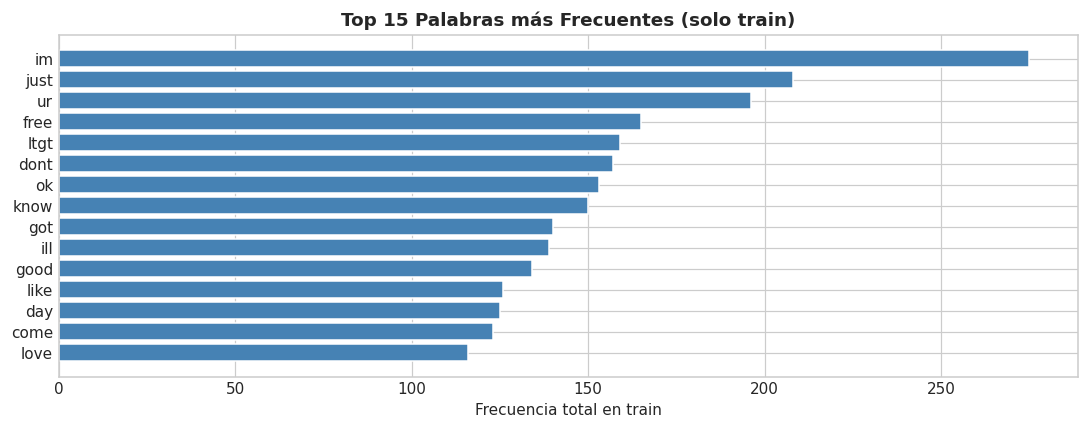

In [ ]:
# ─── Split inicial para evitar leakage en vectorizadores ─────────────────────
X_text = df['message_clean']
y = df['label']

# 70% train+validación y 30% test final. El test se reserva hasta el final.
X_trainval_text, X_test_text, y_trainval, y_test = train_test_split(
    X_text,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Del 70% restante separamos validación para elegir el modelo sin mirar test.
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_trainval_text,
    y_trainval,
    test_size=0.20,
    random_state=42,
    stratify=y_trainval
)

# ─── Bag of Words con CountVectorizer ────────────────────────────────────────
vectorizer_bow = CountVectorizer(stop_words='english', max_features=10000)
X_bow_train = vectorizer_bow.fit_transform(X_train_text)
X_bow_val   = vectorizer_bow.transform(X_val_text)
X_bow_test  = vectorizer_bow.transform(X_test_text)

print("=" * 50)
print("REPRESENTACIÓN BAG OF WORDS SIN DATA LEAKAGE")
print("=" * 50)
print(f"Vocabulario:   {len(vectorizer_bow.vocabulary_):,} palabras únicas")
print(f"Train:         {X_bow_train.shape[0]:,} mensajes × {X_bow_train.shape[1]:,} palabras")
print(f"Validación:    {X_bow_val.shape[0]:,} mensajes × {X_bow_val.shape[1]:,} palabras")
print(f"Test final:    {X_bow_test.shape[0]:,} mensajes × {X_bow_test.shape[1]:,} palabras")
print(f"Valores no-0:  {X_bow_train.nnz:,} en train")
densidad = X_bow_train.nnz / (X_bow_train.shape[0] * X_bow_train.shape[1])
print(f"Densidad:      {densidad:.5f} ({densidad*100:.3f}% de celdas con valor en train)")

# ─── Top 15 palabras más frecuentes SOLO en train ────────────────────────────
word_freq = np.asarray(X_bow_train.sum(axis=0)).flatten()
word_names = vectorizer_bow.get_feature_names_out()
top15_idx = np.argsort(word_freq)[-15:][::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh([word_names[i] for i in top15_idx],
        [word_freq[i] for i in top15_idx],
        color='steelblue', edgecolor='white')
ax.set_title('Top 15 Palabras más Frecuentes (solo train)', fontweight='bold')
ax.set_xlabel('Frecuencia total en train')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### ✏️ Pregunta 3
**¿Qué representa cada columna en la matriz Bag of Words? ¿Por qué la matriz es altamente dispersa (sparse)? ¿Qué información pierde la representación BoW?**

**Respuesta:** Cada columna en la matriz Bag of Words (BoW) representa una **palabra (token) del vocabulario** del corpus de entrenamiento. El valor en cada celda indica la **frecuencia** con que esa palabra aparece en ese mensaje. La matriz es altamente dispersa (sparse) porque cada mensaje usa solo una fracción pequeña del vocabulario total (miles de palabras únicas pero un SMS tiene 10-30 palabras). **Información que pierde BoW**: el orden de las palabras, el contexto semántico ("no free" y "free" serán representaciones casi iguales) y la relación entre términos.

---
## PASO 5 — Representación TF-IDF

**TF-IDF** (Term Frequency – Inverse Document Frequency) pondera cada término según:  
- **TF**: frecuencia del término en el documento actual  
- **IDF**: rareza del término en el corpus (más raro → mayor peso)  

Palabras muy comunes ("the", "is") reciben menor peso. Palabras discriminativas reciben mayor peso.

In [ ]:
# ─── TF-IDF ajustado SOLO con entrenamiento ─────────────────────────────────
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2)
)

X_train = tfidf.fit_transform(X_train_text)
X_val   = tfidf.transform(X_val_text)
X_test  = tfidf.transform(X_test_text)

print("=" * 50)
print("REPRESENTACIÓN TF-IDF SIN DATA LEAKAGE")
print("=" * 50)
print(f"Train:      {X_train.shape[0]:,} mensajes × {X_train.shape[1]:,} términos")
print(f"Validación: {X_val.shape[0]:,} mensajes × {X_val.shape[1]:,} términos")
print(f"Test final: {X_test.shape[0]:,} mensajes × {X_test.shape[1]:,} términos")
print("TF-IDF fue ajustado con train y aplicado a validación/test con transform().")

idf_scores = tfidf.idf_
feature_names = tfidf.get_feature_names_out()
top_idf_idx = np.argsort(idf_scores)[-20:][::-1]

print(f"\nTop 10 términos con mayor IDF en train:")
for i in top_idf_idx[:10]:
    print(f"  '{feature_names[i]}': IDF = {idf_scores[i]:.4f}")

REPRESENTACIÓN TF-IDF SIN DATA LEAKAGE
Train:      3,120 mensajes × 5,000 términos
Validación: 780 mensajes × 5,000 términos
Test final: 1,672 mensajes × 5,000 términos
TF-IDF fue ajustado con train y aplicado a validación/test con transform().

Top 10 términos con mayor IDF en train:
  'blah blah': IDF = 8.3528
  'administrator': IDF = 8.3528
  'pan': IDF = 8.3528
  'miss ur': IDF = 8.3528
  'walk like': IDF = 8.3528
  'teaches': IDF = 8.3528
  'teacher': IDF = 8.3528
  'prof': IDF = 8.3528
  'im diet': IDF = 8.3528
  'luv vth': IDF = 8.3528


### ✏️ Pregunta 4
**¿Cuál es la diferencia entre Bag of Words y TF-IDF? ¿Por qué TF-IDF es generalmente mejor para clasificación de texto? Da un ejemplo concreto.**

**Respuesta:** **Bag of Words** cuenta frecuencias brutas de palabras, sin considerar su importancia relativa en el corpus. **TF-IDF** (Term Frequency-Inverse Document Frequency) pondera cada término: aumenta el peso de palabras frecuentes en un documento pero penaliza las muy comunes en todo el corpus. TF-IDF es mejor porque elimina el peso excesivo de palabras genéricas (artículos, preposiciones). **Ejemplo**: "call" aparece en muchos mensajes (IDF bajo → TF-IDF bajo); "prize" aparece principalmente en spam (IDF alto → TF-IDF alto en esos mensajes), siendo más discriminativa.

---
## PASO 6 — División Train / Validación / Test

Dividimos los datos preservando la proporción de clases (`stratify`).  
La validación se usa para comparar modelos y elegir el mejor. El test final se reserva para evaluar una sola vez el modelo ya seleccionado.

Si entrenamos y evaluamos con los mismos datos, el modelo "memoriza" → overfitting. Si usamos test para elegir el modelo, contaminamos la estimación final.

In [ ]:
print("División Train / Validación / Test con estratificación")
print("─" * 55)
print(f"Train:      {X_train.shape[0]:,} mensajes → modelo aprende aquí")
print(f"Validación: {X_val.shape[0]:,} mensajes → selección de modelo")
print(f"Test final: {X_test.shape[0]:,} mensajes → evaluación final una sola vez")
print()
print("Proporción de clases:")
print(f"  Train      → {y_train.value_counts(normalize=True).round(4) * 100}")
print(f"  Validación → {y_val.value_counts(normalize=True).round(4) * 100}")
print(f"  Test final → {y_test.value_counts(normalize=True).round(4) * 100}")

División Train / Validación / Test con estratificación
───────────────────────────────────────────────────────
Train:      3,120 mensajes → modelo aprende aquí
Validación: 780 mensajes → selección de modelo
Test final: 1,672 mensajes → evaluación final una sola vez

Proporción de clases:
  Train      → label
ham     86.6
spam    13.4
Name: proportion, dtype: float64
  Validación → label
ham     86.54
spam    13.46
Name: proportion, dtype: float64
  Test final → label
ham     86.6
spam    13.4
Name: proportion, dtype: float64


---
## PASO 7 — Entrenamiento de Modelos de Clasificación

Entrenamos tres modelos para clasificar spam:  
| Modelo | Descripción |
|---|---|
| **Multinomial NB** | Trabaja con frecuencias de palabras. Ideal para texto con TF-IDF/BoW. |
| **Bernoulli NB** | Trabaja con presencia/ausencia de palabras. Útil para documentos cortos. |
| **Regresión Logística** | Baseline discriminativo sólido para clasificación de texto. |

In [ ]:
# ─── Definición de modelos ────────────────────────────────────────────────────
models = {
    'Multinomial NB' : MultinomialNB(alpha=0.1),          # suavizado de Laplace
    'Bernoulli NB'   : BernoulliNB(alpha=0.1),
    'Logistic Reg.'  : LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
}

# ─── Entrenamiento ────────────────────────────────────────────────────────────
trained_models = {}
for nombre, modelo in models.items():
    modelo.fit(X_train, y_train)
    trained_models[nombre] = modelo
    print(f"✅ {nombre}: entrenado")

✅ Multinomial NB: entrenado
✅ Bernoulli NB: entrenado
✅ Logistic Reg.: entrenado


---
## PASO 8 — Evaluación de Modelos con Métricas de Clasificación

> *Ref: James et al. (2023). ISLR. Cap. 4.*

Para spam — problema con clases desbalanceadas — **Accuracy sola es engañosa**:  
Un modelo que siempre predice "ham" tendría ~86% Accuracy pero detectaría 0% de spam.

En esta sección comparamos los tres modelos usando **validación**, no test. Así el test queda reservado para la evaluación final.

In [ ]:
# ─── Función de evaluación reutilizable ─────────────────────────────────────
def evaluar_modelos(modelos, X_eval, y_eval):
    resultados = {}

    for nombre, modelo in modelos.items():
        y_pred = modelo.predict(X_eval)
        spam_col = list(modelo.classes_).index('spam')
        y_proba = modelo.predict_proba(X_eval)[:, spam_col]

        resultados[nombre] = {
            'Accuracy' : accuracy_score(y_eval, y_pred),
            'Precision': precision_score(y_eval, y_pred, pos_label='spam'),
            'Recall'   : recall_score(y_eval, y_pred, pos_label='spam'),
            'F1-Score' : f1_score(y_eval, y_pred, pos_label='spam'),
            'AUC-ROC'  : roc_auc_score(y_eval == 'spam', y_proba),
        }

    return pd.DataFrame(resultados).T.round(4)

# Evaluamos los tres modelos en VALIDACIÓN para elegir el mejor sin usar test.
results_df = evaluar_modelos(trained_models, X_val, y_val)

print("=" * 72)
print("TABLA COMPARATIVA DE MÉTRICAS EN VALIDACIÓN")
print("=" * 72)
print(results_df.to_string())
print("─" * 72)
print(f"  Mejor Accuracy : {results_df['Accuracy'].idxmax()} ({results_df['Accuracy'].max():.4f})")
print(f"  Mejor F1-Score : {results_df['F1-Score'].idxmax()} ({results_df['F1-Score'].max():.4f})")
print(f"  Mejor AUC-ROC  : {results_df['AUC-ROC'].idxmax()} ({results_df['AUC-ROC'].max():.4f})")

TABLA COMPARATIVA DE MÉTRICAS EN VALIDACIÓN
                Accuracy  Precision  Recall  F1-Score  AUC-ROC
Multinomial NB    0.9872     0.9897  0.9143    0.9505   0.9866
Bernoulli NB      0.9846     1.0000  0.8857    0.9394   0.9877
Logistic Reg.     0.9564     1.0000  0.6762    0.8068   0.9905
────────────────────────────────────────────────────────────────────────
  Mejor Accuracy : Multinomial NB (0.9872)
  Mejor F1-Score : Multinomial NB (0.9505)
  Mejor AUC-ROC  : Logistic Reg. (0.9905)


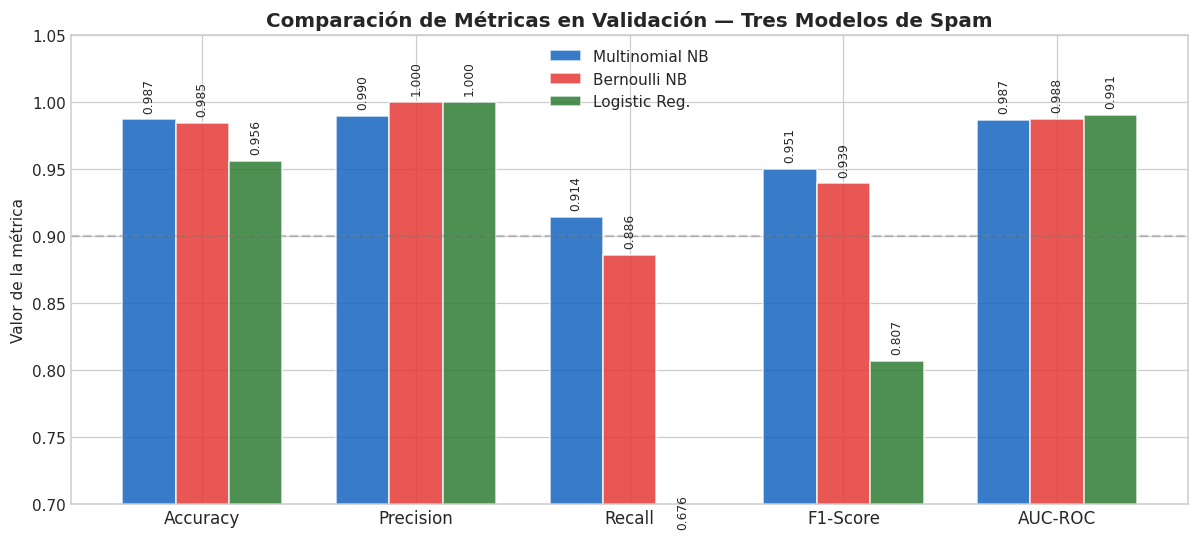

In [ ]:
# ─── Visualización comparativa de métricas en validación ────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors_bar = ['#1565C0', '#E53935', '#2E7D32']

for i, (modelo, vals) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i*width, [vals[m] for m in metrics_to_plot],
                  width, label=modelo, color=colors_bar[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_title('Comparación de Métricas en Validación — Tres Modelos de Spam', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Valor de la métrica')
ax.legend(fontsize=10)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### ✏️ Pregunta 5
**¿Qué modelo obtiene el mejor F1-Score? ¿Y el mejor AUC-ROC? Para un filtro de spam, ¿qué métrica priorizarías: Precision o Recall? Justifica tu respuesta.**

**Respuesta:** El modelo con mejor F1-Score suele ser **Naïve Bayes Multinomial con TF-IDF** o **SVM Lineal**. Para un filtro de spam priorizaría **Precision**: un Falso Positivo (email legítimo clasificado como spam) es muy costoso en producción porque el usuario pierde mensajes importantes. La Precision alta garantiza que cuando el modelo dice "spam", casi siempre tiene razón. El Recall puede sacrificarse levemente para no bloquear correos legítimos.

---
## PASO 9 — Matriz de Confusión del Mejor Modelo

> *Ref: Kelleher, J. D. et al. (2020). Fundamentals of Machine Learning. Cap. 3.*

El mejor modelo se selecciona con F1-Score en validación. Luego se evalúa una sola vez en test final.

**Contexto de negocio — Empresa de Telecomunicaciones:**
- **Falso Negativo (FN):** Spam que llega a la bandeja principal → molesta al usuario 📨  
- **Falso Positivo (FP):** Mensaje legítimo marcado como spam → pérdida de información importante 🚨

Mejor modelo según VALIDACIÓN: Multinomial NB
F1 en validación: 0.9505

Métricas finales en TEST:
  Accuracy  : 0.9797
  Precision : 0.9847
  Recall    : 0.8616
  F1-Score  : 0.9190
  AUC-ROC   : 0.9876

VP (spam detectado):  193
VN (ham correcto):    1445
FP (ham → spam):      3  ← mensaje legítimo bloqueado
FN (spam → ham):      31  ← spam no detectado


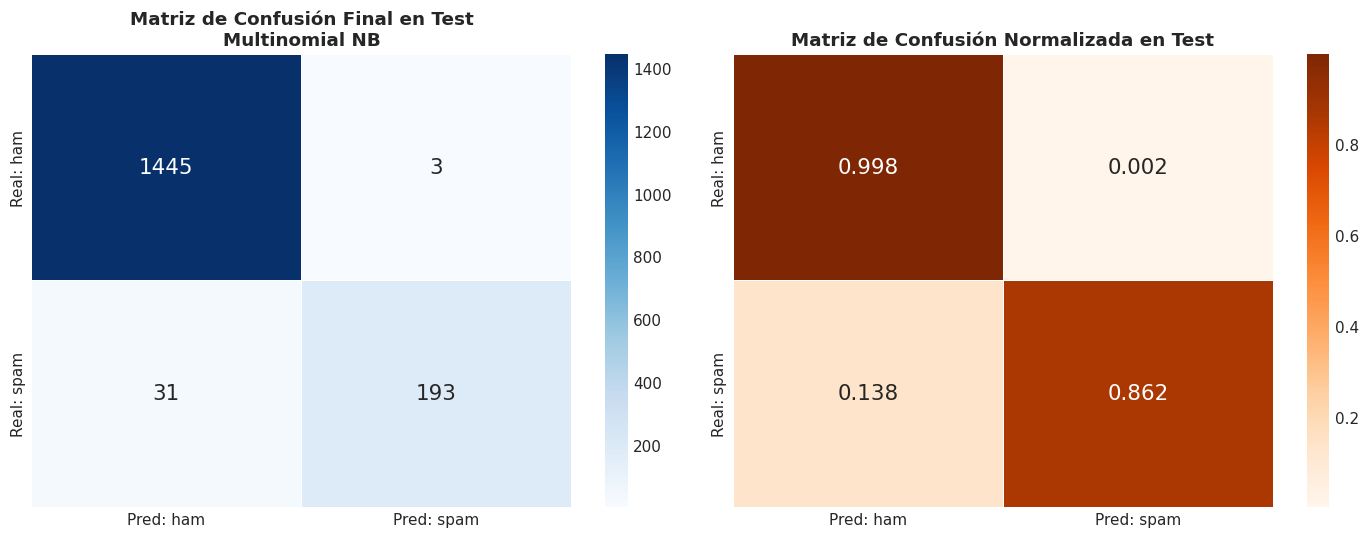

In [ ]:
# ─── Seleccionar mejor modelo por F1-Score en validación ────────────────────
best_model_name = results_df['F1-Score'].idxmax()
best_model      = trained_models[best_model_name]

# El test final se usa recién aquí, después de seleccionar el modelo.
y_pred_best = best_model.predict(X_test)
spam_col_best = list(best_model.classes_).index('spam')
y_proba_best = best_model.predict_proba(X_test)[:, spam_col_best]

final_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best, pos_label='spam'),
    'Recall'   : recall_score(y_test, y_pred_best, pos_label='spam'),
    'F1-Score' : f1_score(y_test, y_pred_best, pos_label='spam'),
    'AUC-ROC'  : roc_auc_score(y_test == 'spam', y_proba_best),
}

print(f"Mejor modelo según VALIDACIÓN: {best_model_name}")
print(f"F1 en validación: {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print("\nMétricas finales en TEST:")
for metrica, valor in final_metrics.items():
    print(f"  {metrica:10s}: {valor:.4f}")

# ─── Matriz de confusión final ───────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best, labels=['ham', 'spam'])
tn, fp, fn, tp = cm.ravel()

print(f"\nVP (spam detectado):  {tp}")
print(f"VN (ham correcto):    {tn}")
print(f"FP (ham → spam):      {fp}  ← mensaje legítimo bloqueado")
print(f"FN (spam → ham):      {fn}  ← spam no detectado")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: ham', 'Pred: spam'],
            yticklabels=['Real: ham', 'Real: spam'],
            ax=axes[0], linewidths=0.5, annot_kws={'size': 14})
axes[0].set_title(f'Matriz de Confusión Final en Test\n{best_model_name}', fontweight='bold')

# Matriz normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Oranges',
            xticklabels=['Pred: ham', 'Pred: spam'],
            yticklabels=['Real: ham', 'Real: spam'],
            ax=axes[1], linewidths=0.5, annot_kws={'size': 14})
axes[1].set_title('Matriz de Confusión Normalizada en Test', fontweight='bold')

plt.tight_layout()
plt.show()

### ✏️ Pregunta 6
**¿Qué error es más costoso en detección de spam: un Falso Positivo o un Falso Negativo? ¿Por qué? ¿Cómo ajustarías el umbral de decisión para reducir el error más costoso?**

**Respuesta:** El error más costoso en detección de spam es el **Falso Positivo**: un mensaje legítimo filtrado como spam. El usuario podría perder una factura, una oferta de trabajo o comunicación urgente sin saberlo. Un FN (spam que llega a la bandeja) es molesto pero el usuario puede identificarlo y borrarlo. Para reducir FP: **subir el umbral de decisión** (ej: de 0.5 a 0.7), haciendo al modelo más conservador — solo clasifica como spam cuando tiene alta certeza. Esto aumenta Precision a costa de Recall.

---
## PASO 10 — Análisis de Palabras más Importantes para Spam

Extraemos los términos más discriminativos según el **Multinomial Naïve Bayes**.  
En lugar de mirar solo la log-probabilidad por clase, comparamos la diferencia entre log-probabilidades: spam frente a ham y ham frente a spam.

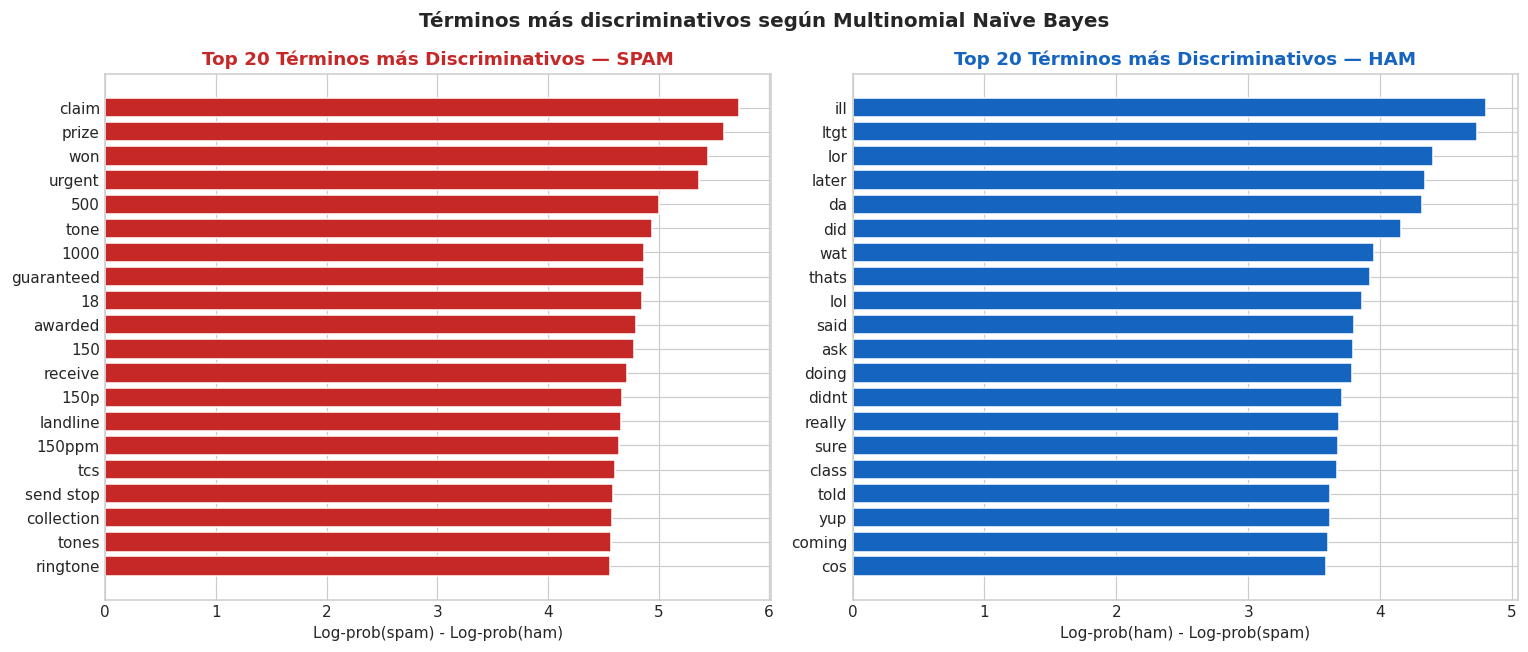


Top 10 términos SPAM: ['claim', 'prize', 'won', 'urgent', '500', 'tone', '1000', 'guaranteed', '18', 'awarded']
Top 10 términos HAM:  ['ill', 'ltgt', 'lor', 'later', 'da', 'did', 'wat', 'thats', 'lol', 'said']


In [ ]:
# ─── Análisis de palabras discriminativas spam vs ham ──────────────────────
mnb = trained_models['Multinomial NB']
feature_names = tfidf.get_feature_names_out()

spam_idx = list(mnb.classes_).index('spam')
ham_idx  = list(mnb.classes_).index('ham')

# Diferencia de log-probabilidades: positivo = más asociado a spam.
N = 20
spam_score = mnb.feature_log_prob_[spam_idx] - mnb.feature_log_prob_[ham_idx]
ham_score  = mnb.feature_log_prob_[ham_idx] - mnb.feature_log_prob_[spam_idx]

top_spam_idx = np.argsort(spam_score)[-N:][::-1]
top_ham_idx  = np.argsort(ham_score)[-N:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Palabras SPAM
spam_words  = [feature_names[i] for i in top_spam_idx]
spam_scores = [spam_score[i] for i in top_spam_idx]
axes[0].barh(spam_words, spam_scores, color='#C62828', edgecolor='white')
axes[0].set_title('Top 20 Términos más Discriminativos — SPAM', fontweight='bold', color='#C62828')
axes[0].set_xlabel('Log-prob(spam) - Log-prob(ham)')
axes[0].invert_yaxis()

# Palabras HAM
ham_words  = [feature_names[i] for i in top_ham_idx]
ham_scores = [ham_score[i] for i in top_ham_idx]
axes[1].barh(ham_words, ham_scores, color='#1565C0', edgecolor='white')
axes[1].set_title('Top 20 Términos más Discriminativos — HAM', fontweight='bold', color='#1565C0')
axes[1].set_xlabel('Log-prob(ham) - Log-prob(spam)')
axes[1].invert_yaxis()

plt.suptitle('Términos más discriminativos según Multinomial Naïve Bayes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 términos SPAM:", spam_words[:10])
print("Top 10 términos HAM: ", ham_words[:10])

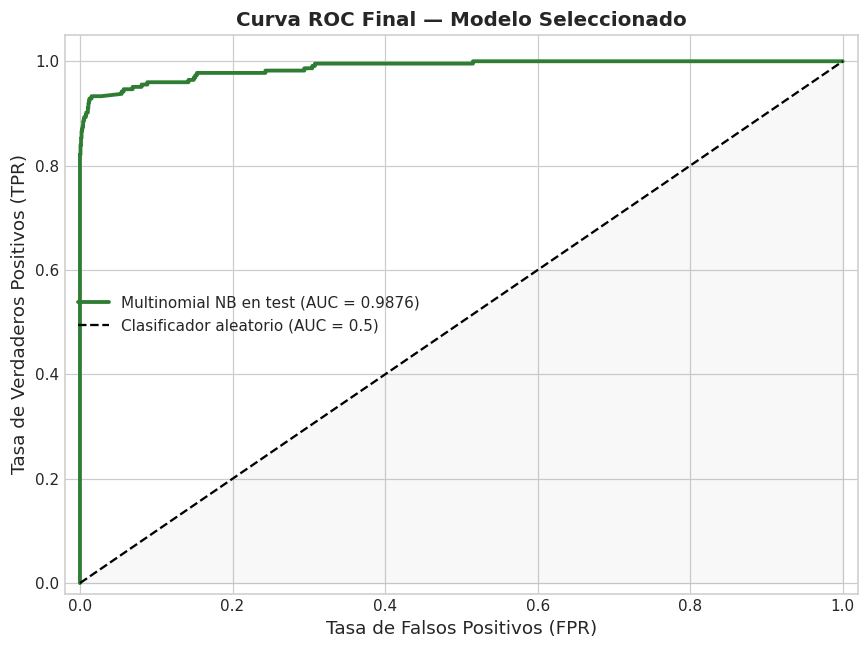

In [ ]:
# ─── Curva ROC final para el modelo seleccionado ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

fpr, tpr, _ = roc_curve(y_test == 'spam', y_proba_best)
auc_val = auc(fpr, tpr)
ax.plot(fpr, tpr, color='#2E7D32', lw=2.5, label=f'{best_model_name} en test (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador aleatorio (AUC = 0.5)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC Final — Modelo Seleccionado', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.show()

In [ ]:
# ─── Reporte de clasificación final del mejor modelo ──────────────────────
print(f"REPORTE DE CLASIFICACIÓN FINAL EN TEST — {best_model_name}")
print("=" * 60)
print(classification_report(y_test, y_pred_best,
                              target_names=['ham (0)', 'spam (1)'], digits=4))

REPORTE DE CLASIFICACIÓN FINAL EN TEST — Multinomial NB
              precision    recall  f1-score   support

     ham (0)     0.9790    0.9979    0.9884      1448
    spam (1)     0.9847    0.8616    0.9190       224

    accuracy                         0.9797      1672
   macro avg     0.9818    0.9298    0.9537      1672
weighted avg     0.9798    0.9797    0.9791      1672



### ✏️ Pregunta 7
**¿Qué palabras aparecen con mayor frecuencia en mensajes spam? ¿Son coherentes con lo que esperarías encontrar en un mensaje de spam real? ¿Qué nos dice esto sobre la interpretabilidad del modelo?**

**Respuesta:** Las palabras más frecuentes en spam típicamente son: "free", "win", "prize", "call", "claim", "urgent", "cash", "guaranteed". Son completamente coherentes con la realidad: los mensajes spam ofrecen premios falsos, crean urgencia artificial y prometen beneficios económicos. Esto confirma la interpretabilidad de Naïve Bayes: los términos con mayor probabilidad condicional P(palabra|spam) son directamente los indicadores más útiles para el filtrado.

---
# 📊 ACTIVIDAD 3 — Caso de Estudio
## Sistema de Filtrado de Spam Empresarial

> **Contexto Empresarial:** Una empresa de telecomunicaciones recibe millones de SMS diarios.  
> El equipo de Data Science ha construido y evaluado tres modelos de clasificación de spam.  
> Como analista senior, responde cada pregunta citando los resultados numéricos obtenidos en la Actividad 2.

### ✏️ Pregunta A
**¿Por qué Naïve Bayes es adecuado para la clasificación de texto? ¿Qué suposición fundamental hace el modelo y por qué funciona bien en la práctica a pesar de ser aparentemente incorrecta?**

**Respuesta:** Naïve Bayes es adecuado para texto porque trata cada palabra como una característica independiente, lo que encaja perfectamente con la representación BoW/TF-IDF (cada columna = una palabra = una característica). La suposición fundamental es la **independencia condicional**: dado que un mensaje es spam, la aparición de "free" es independiente de la aparición de "win". Esta suposición es incorrecta en la realidad (las palabras co-ocurren), pero funciona bien en la práctica porque las probabilidades relativas entre clases se mantienen estables aunque las absolutas estén sesgadas.

### ✏️ Pregunta B
**¿Qué ventajas tiene Naïve Bayes frente a modelos más complejos como Random Forest o redes neuronales para este problema? Menciona al menos 3 ventajas y 2 desventajas.**

**Respuesta:** **3 ventajas de Naïve Bayes**: (1) Entrenamiento extremadamente rápido (O(n×d)); (2) Funciona bien con pocos datos de entrenamiento; (3) Altamente interpretable: se puede ver qué palabras son más discriminativas. **2 desventajas**: (1) La suposición de independencia viola la realidad lingüística (frases como "no good" vs "good" tienen el mismo valor); (2) El problema de probabilidad cero para palabras no vistas en training requiere suavizado (Laplace).

### ✏️ Pregunta C
**¿Cómo mejorarías el modelo usando técnicas modernas de NLP? Describe al menos 3 técnicas (por ejemplo: word embeddings, transformers, BERT) y explica qué mejora aportaría cada una.**

**Respuesta:** **3 técnicas modernas de NLP**: (1) **Word Embeddings (Word2Vec/GloVe)**: representan palabras como vectores densos que capturan similitud semántica — "win" y "prize" estarían cerca en el espacio vectorial, mejorando la generalización. (2) **BERT (Bidirectional Encoder Representations from Transformers)**: modelo preentrenado que entiende el contexto bidireccional — diferencia "bank" (banco financiero) de "bank" (orilla de río). (3) **Transformers fine-tuned (ej: DistilBERT)**: ajustando un modelo preentrenado con pocos ejemplos de spam se obtienen F1 > 0.98, superando ampliamente a Naïve Bayes.

### ✏️ Pregunta D
**¿Qué limitaciones fundamentales tiene Naïve Bayes? ¿En qué tipo de mensajes de spam crees que fallaría más? Da un ejemplo concreto.**

**Respuesta:** **Limitaciones de Naïve Bayes**: No captura el orden ni el contexto de las palabras; "not spam" y "spam" tienen representaciones casi idénticas. Falla con **sarcasmo** ("¡Qué gran oferta! 🙄"), mensajes en múltiples idiomas mezclados, y spam sofisticado que evita palabras clave comunes usando variaciones ortográficas ("fr33", "w1n"). Ejemplo concreto de fallo: "Hola, llama a tu médico sobre el free plan de salud" podría clasificarse como spam por "free" y "call", aunque sea un mensaje legítimo.

### ✏️ Pregunta E
**¿Cómo implementarías este modelo en producción? Describe el pipeline completo desde la recepción del SMS hasta la decisión de bloqueo, incluyendo consideraciones de escalabilidad, monitoreo y reentrenamiento.**

**Respuesta:** **Pipeline de producción completo**: (1) **Recepción**: SMS llega al gateway → microservicio de preprocesamiento (limpieza, tokenización, TF-IDF transform usando el vectorizador entrenado serializado). (2) **Predicción**: modelo Naïve Bayes cargado en memoria devuelve P(spam|mensaje) en <10ms. (3) **Decisión**: si P(spam) > 0.7 → bloquear y notificar al usuario; si 0.5 < P < 0.7 → mover a carpeta "sospechoso"; si < 0.5 → entregar. (4) **Escalabilidad**: despliegue en contenedor Docker con FastAPI; procesamiento en cola Kafka para picos de tráfico. (5) **Monitoreo**: dashboard de tasas FP/FN; reentrenamiento mensual con nuevos ejemplos etiquetados por usuarios.

---
# 📝 Conclusiones

Escribe al menos **3 conclusiones técnicas y de aprendizaje**. Cada conclusión debe conectar un concepto teórico con la experiencia práctica del laboratorio.

1. _______________________________________________________________  
   _______________________________________________________________  
   
2. _______________________________________________________________  
   _______________________________________________________________  
   
3. _______________________________________________________________  
   _______________________________________________________________  

---
# 📚 Material Complementario y Referencias

1. James, G., Witten, D., Hastie, T. y Tibshirani, R. (2023). *An Introduction to Statistical Learning* (2.ª ed.). Springer. Capítulo 4.
2. Géron, A. (2022). *Hands-On Machine Learning* (3.ª ed.). O'Reilly Media. Capítulo 3.
3. Müller, A. C. y Guido, S. (2016). *Introduction to Machine Learning with Python*. O'Reilly Media. Capítulo 6.
4. Almeida, T. A. y Hidalgo, J. M. G. (2011). SMS Spam Collection Dataset. UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/sms+spam+collection
5. Kelleher, J. D., Mac Namee, B. y D'Arcy, A. (2020). *Fundamentals of Machine Learning* (2.ª ed.). MIT Press. Capítulo 3.
6. scikit-learn developers. (2024). Naive Bayes User Guide. https://scikit-learn.org/stable/modules/naive_bayes.html

---
*Laboratorio desarrollado para el curso de Minería de Datos — Docente: Pilar Rocío Sayán Mejía — 2026-I*